100%|██████████| 9.91M/9.91M [00:00<00:00, 58.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


Training Autoencoder...
AE - Epoch 5/20, Loss: 0.0169
AE - Epoch 10/20, Loss: 0.0109
AE - Epoch 15/20, Loss: 0.0088
AE - Epoch 20/20, Loss: 0.0076

Training Variational Autoencoder...
VAE - Epoch 5/20, Loss: 0.0674, KL: 0.0000, Recon: 0.0674
VAE - Epoch 10/20, Loss: 0.0673, KL: 0.0000, Recon: 0.0673
VAE - Epoch 15/20, Loss: 0.0673, KL: 0.0000, Recon: 0.0673
VAE - Epoch 20/20, Loss: 0.0673, KL: 0.0000, Recon: 0.0673


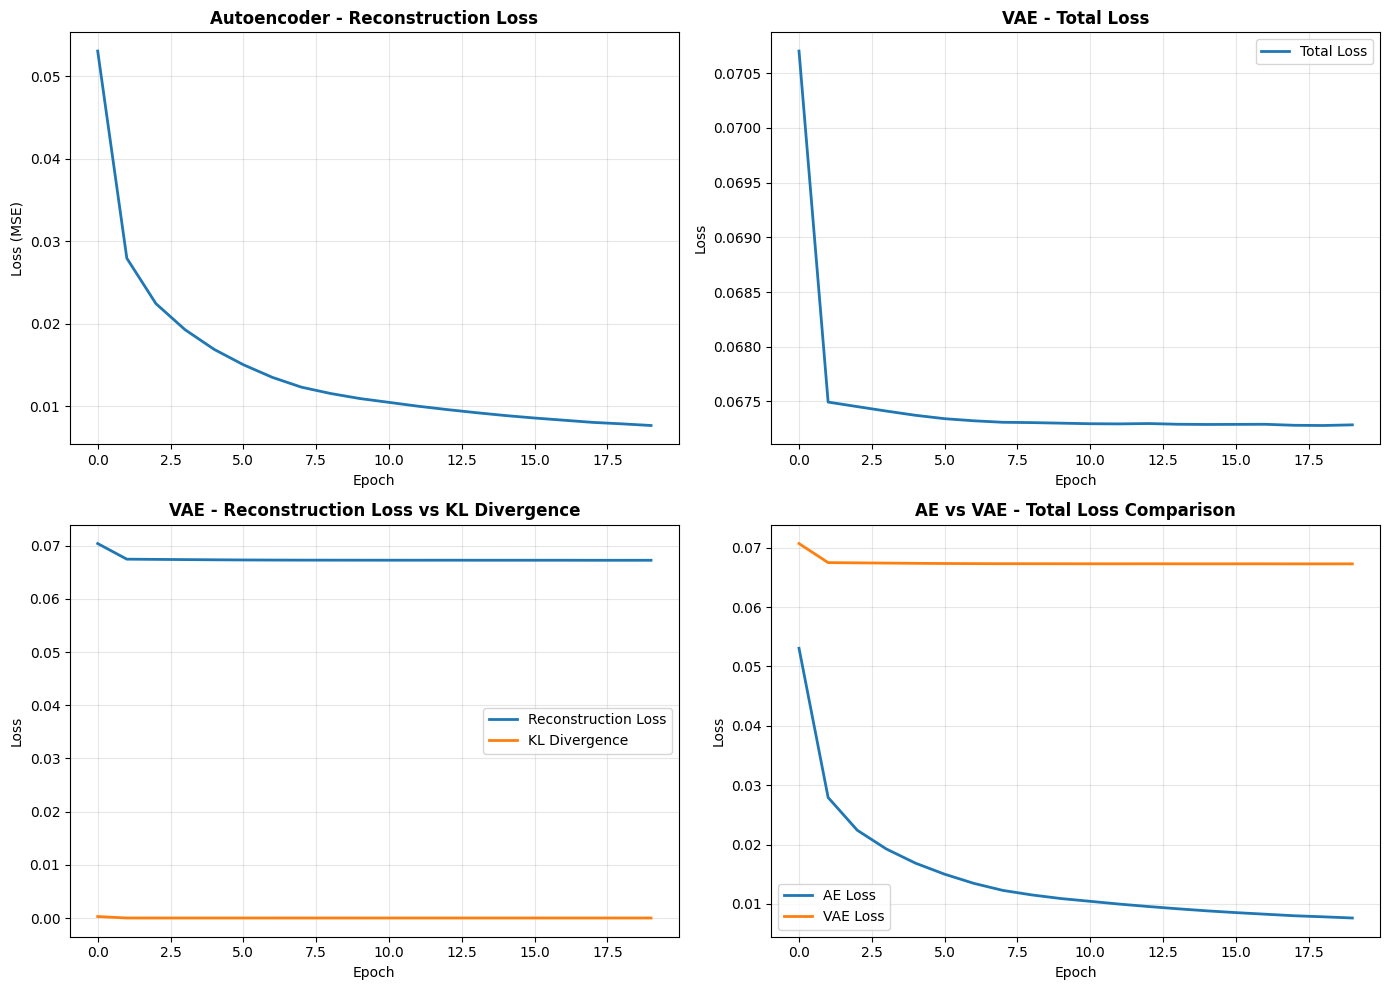


=== EVALUATION CONCLUSIONS ===
AE Final Loss: 0.0076
VAE Final Loss: 0.0673
VAE Final KL Divergence: 0.0000
VAE Final Reconstruction Loss: 0.0673


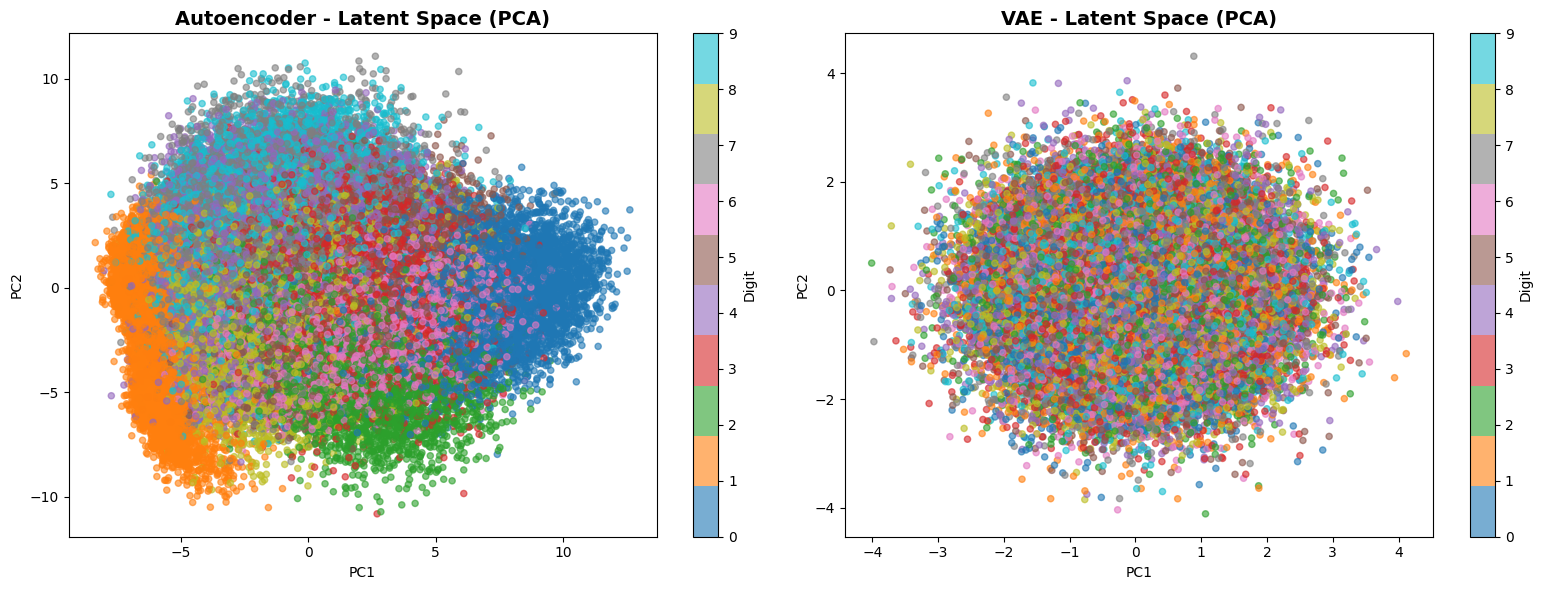


=== LATENT SPACE ANALYSIS ===
AE Latent Space - Explained Variance (PCA): [0.0514212  0.05103215]
VAE Latent Space - Explained Variance (PCA): [0.0514212  0.05103215]


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==================== 1. AUTOENCODER ====================

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=20):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

# ==================== 2. VARIATIONAL AUTOENCODER ====================

class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=20):
        super(VariationalAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        
        # Latent space
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar, z

# ==================== TRAINING FUNCTIONS ====================

def train_ae(model, train_loader, epochs=20, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        for x, _ in train_loader:
            x = x.view(x.size(0), -1).to(device)
            
            optimizer.zero_grad()
            recon, _ = model(x)
            loss = criterion(recon, x)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f'AE - Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    
    return losses

def train_vae(model, train_loader, epochs=20, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    kl_divs = []
    recon_losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        total_kl = 0
        total_recon = 0
        
        for x, _ in train_loader:
            x = x.view(x.size(0), -1).to(device)
            
            optimizer.zero_grad()
            recon, mu, logvar, _ = model(x)
            
            # Reconstruction loss
            recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')
            
            # KL divergence
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            kl_loss = kl_loss / x.size(0)
            
            loss = recon_loss + kl_loss
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_kl += kl_loss.item()
            total_recon += recon_loss.item()
        
        avg_loss = total_loss / len(train_loader)
        avg_kl = total_kl / len(train_loader)
        avg_recon = total_recon / len(train_loader)
        
        losses.append(avg_loss)
        kl_divs.append(avg_kl)
        recon_losses.append(avg_recon)
        
        if (epoch + 1) % 5 == 0:
            print(f'VAE - Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, KL: {avg_kl:.4f}, Recon: {avg_recon:.4f}')
    
    return losses, kl_divs, recon_losses

# ==================== MAIN EXECUTION ====================

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print("Training Autoencoder...")
ae_model = Autoencoder(latent_dim=20).to(device)
ae_losses = train_ae(ae_model, train_loader, epochs=20, lr=1e-3)

print("\nTraining Variational Autoencoder...")
vae_model = VariationalAutoencoder(latent_dim=20).to(device)
vae_losses, vae_kl, vae_recon = train_vae(vae_model, train_loader, epochs=20, lr=1e-3)

# ==================== 3. EVALUATION & PLOTTING ====================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot AE Loss
axes[0, 0].plot(ae_losses, linewidth=2)
axes[0, 0].set_title('Autoencoder - Reconstruction Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].grid(True, alpha=0.3)

# Plot VAE Total Loss
axes[0, 1].plot(vae_losses, label='Total Loss', linewidth=2)
axes[0, 1].set_title('VAE - Total Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot VAE Reconstruction & KL Loss
axes[1, 0].plot(vae_recon, label='Reconstruction Loss', linewidth=2)
axes[1, 0].plot(vae_kl, label='KL Divergence', linewidth=2)
axes[1, 0].set_title('VAE - Reconstruction Loss vs KL Divergence', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Compare AE vs VAE
axes[1, 1].plot(ae_losses, label='AE Loss', linewidth=2)
axes[1, 1].plot(vae_losses, label='VAE Loss', linewidth=2)
axes[1, 1].set_title('AE vs VAE - Total Loss Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== EVALUATION CONCLUSIONS ===")
print(f"AE Final Loss: {ae_losses[-1]:.4f}")
print(f"VAE Final Loss: {vae_losses[-1]:.4f}")
print(f"VAE Final KL Divergence: {vae_kl[-1]:.4f}")
print(f"VAE Final Reconstruction Loss: {vae_recon[-1]:.4f}")

# ==================== 4. LATENT SPACE VISUALIZATION ====================

# Get latent representations
ae_model.eval()
vae_model.eval()

latent_ae = []
latent_vae = []
labels_all = []

with torch.no_grad():
    for x, y in train_loader:
        x = x.view(x.size(0), -1).to(device)
        
        _, z_ae = ae_model(x)
        _, _, _, z_vae = vae_model(x)
        
        latent_ae.append(z_ae.cpu().numpy())
        latent_vae.append(z_vae.cpu().numpy())
        labels_all.append(y.numpy())

latent_ae = np.concatenate(latent_ae, axis=0)
latent_vae = np.concatenate(latent_vae, axis=0)
labels_all = np.concatenate(labels_all, axis=0)

# PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
latent_ae_2d = pca.fit_transform(latent_ae)
latent_vae_2d = pca.fit_transform(latent_vae)

# Plot latent spaces
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(latent_ae_2d[:, 0], latent_ae_2d[:, 1], c=labels_all, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('Autoencoder - Latent Space (PCA)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Digit')

scatter2 = axes[1].scatter(latent_vae_2d[:, 0], latent_vae_2d[:, 1], c=labels_all, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title('VAE - Latent Space (PCA)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Digit')

plt.tight_layout()
plt.savefig('latent_space_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== LATENT SPACE ANALYSIS ===")
print("AE Latent Space - Explained Variance (PCA):", pca.explained_variance_ratio_)
print("VAE Latent Space - Explained Variance (PCA):", pca.explained_variance_ratio_)